In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# DenseNet201 ‑ Fine‑Tuning para Clasificación Multiclase de Neumonía  
*Versión `multiclass/` - Primer dataser (bacterial · viral · normal)*  

---

## 1. Parámetros principales
| Parámetro        | Valor                            |
|------------------|----------------------------------|
| **IMG_SIZE**     | (224 × 224)                      |
| **BATCH_SIZE**   | 16                               |
| **NUM_CLASSES**  | 3  (`NORMAL`, `PNEUMONIA‑BACTERIAL`, `PNEUMONIA‑VIRAL`) |
| **TRAIN_DIR**    | `/workspace/multiclass/train`    |
| **VAL_DIR**      | `/workspace/multiclass/val`      |

---

## 2. Pipeline de datos
- **Carga** con `tf.keras.utils.image_dataset_from_directory`  
  - `label_mode='categorical'`, `shuffle=True` (train) / `False` (val)  
- **Prefetch & Cache**: `AUTOTUNE` para optimizar I/O.

---

## 3. Arquitectura del modelo
1. **Backbone**: `DenseNet201` *(pre‑entrenada ImageNet, sin top)*  
   - **Fase 1**: congelada.  
   - **Fase 2**: se descongelan capas **500 → fin** (*fine‑tuning*).  
2. **Cabeza personalizada**  

## 4. Entrenamiento
| Fase | Capas entrenables | LR | Épocas | Observaciones |
|------|------------------|----|--------|---------------|
| **1. Cabeza** | Solo cabeza | 1 × 10‑4 (con scheduler) | 10 | Val. accuracy se estancó ≈ 0.36 |
| **2. Fine‑tuning** | Backbone 500+ | 1 × 10‑5 (con scheduler) | 10 | Val. accuracy sube a **0.50** |

**Callbacks:** `EarlyStopping(patience=5)`, `ReduceLROnPlateau(factor = 0.2, patience = 2)`, `ModelCheckpoint(best_densenet_model.h5)`.

---

## 5. Resultados finales (VAL, 22 imágenes)
| Métrica global | Valor |
|----------------|-------|
| **Accuracy**   | **0.50** |
| **F1‑ponderado** | **0.51** |

| Clase                 | Precisión | Recall | F1 |
|-----------------------|-----------|--------|----|
| **NORMAL**            | 1.00 | 0.38 | 0.55 |
| **PNEUMONIA‑BACTERIAL** | 0.44 | 0.57 | 0.50 |
| **PNEUMONIA‑VIRAL**     | 0.40 | 0.57 | 0.47 |

> El modelo mejora hasta 50 % de exactitud tras fine‑tuning, pero persiste desequilibrio entre precisión y recall, especialmente en `NORMAL`.

---

In [1]:
# ======================
# 1. Importaciones
# ======================
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


2025-07-04 22:35:22.553959: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# ======================
# 2. Parámetros
# ======================
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 3  # bacterial, viral, normal

# ======================
# 3. Carga del dataset desde tf.data
# Set paths
TRAIN_DIR = "/workspace/multiclass/train"
# ======================
train_dir = "/workspace/multiclass/train"
val_dir   ="/workspace/multiclass/val"



train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Mejora: prefetch para eficiencia
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 5292 files belonging to 3 classes.


2025-07-04 22:36:36.589550: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-04 22:36:36.607881: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-04 22:36:36.608172: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-04 22:36:36.609796: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-04 22:36:36.610120: I tensorflow/compile

Found 22 files belonging to 3 classes.


In [5]:
# ======================
# 4. Construcción del modelo con fine-tuning y regularización
# ======================
base_model = DenseNet201(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False  # Etapa 1: congelado

x = base_model.output
x = GlobalAveragePooling2D()(x)    # Reduce dimensiones conservando características
x = BatchNormalization()(x)        # Normaliza activaciones para estabilidad
x = Dropout(0.5)(x)                # Evita overfitting
x = Dense(128, activation='relu')(x)  # Capa densa con activación no lineal
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)  # Capa de salida para 3 clases

model = Model(inputs=base_model.input, outputs=output)

In [7]:
# ======================
# 5. Compilación
# ======================
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ======================
# 6. Callbacks
# ======================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1),
    ModelCheckpoint("best_densenet_model.h5", save_best_only=True)
]

In [9]:
# ======================
# 7. Entrenamiento (fase 1: cabeza)
# ======================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
331/331 [==============================] - 20s 61ms/step - loss: 0.9020 - accuracy: 0.5797 - val_loss: 1.3484 - val_accuracy: 0.3636 - lr: 4.0000e-06
Epoch 2/10
331/331 [==============================] - 20s 59ms/step - loss: 0.8802 - accuracy: 0.5926 - val_loss: 1.3433 - val_accuracy: 0.3636 - lr: 4.0000e-06
Epoch 3/10
331/331 [==============================] - 19s 57ms/step - loss: 0.8726 - accuracy: 0.6045 - val_loss: 1.3500 - val_accuracy: 0.3636 - lr: 4.0000e-06
Epoch 4/10
331/331 [==============================] - ETA: 0s - loss: 0.8591 - accuracy: 0.6017
Epoch 4: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.
331/331 [==============================] - 19s 58ms/step - loss: 0.8591 - accuracy: 0.6017 - val_loss: 1.3564 - val_accuracy: 0.3636 - lr: 4.0000e-06
Epoch 5/10
331/331 [==============================] - 19s 58ms/step - loss: 0.8652 - accuracy: 0.5977 - val_loss: 1.3597 - val_accuracy: 0.3636 - lr: 8.0000e-07
Epoch 6/10
330/331 [==============

In [10]:
# ======================
# 8. Fine-tuning (fase 2: descongelar capas superiores)
# ======================
base_model.trainable = True

# Descongelamos desde la capa 500 en adelante (ajustable)
for layer in base_model.layers[:500]:
    layer.trainable = False

# Recompilar con learning rate pequeño
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Segunda fase de entrenamiento
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
331/331 [==============================] - 70s 119ms/step - loss: 1.0105 - accuracy: 0.5567 - val_loss: 1.0957 - val_accuracy: 0.5000 - lr: 1.0000e-05
Epoch 2/10
331/331 [==============================] - 30s 89ms/step - loss: 0.8212 - accuracy: 0.6160 - val_loss: 1.1734 - val_accuracy: 0.4091 - lr: 1.0000e-05
Epoch 3/10
331/331 [==============================] - ETA: 0s - loss: 0.7397 - accuracy: 0.6536
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
331/331 [==============================] - 29s 88ms/step - loss: 0.7397 - accuracy: 0.6536 - val_loss: 1.1834 - val_accuracy: 0.4091 - lr: 1.0000e-05
Epoch 4/10
331/331 [==============================] - 29s 88ms/step - loss: 0.6737 - accuracy: 0.6740 - val_loss: 1.1933 - val_accuracy: 0.4091 - lr: 2.0000e-06
Epoch 5/10
331/331 [==============================] - ETA: 0s - loss: 0.6656 - accuracy: 0.6805
Epoch 5: ReduceLROnPlateau reducing learning rate to 3.999999989900971e-07.
331/331 [============

2/2 [==============================] - 0s 202ms/step
🔍 Accuracy: 0.5
📐 F1 Score (ponderado): 0.5071706368497811

📋 Reporte de Clasificación:
                      precision    recall  f1-score   support

             NORMAL       1.00      0.38      0.55         8
PNEUMONIA-BACTERIAL       0.44      0.57      0.50         7
    PNEUMONIA-VIRAL       0.40      0.57      0.47         7

           accuracy                           0.50        22
          macro avg       0.61      0.51      0.51        22
       weighted avg       0.63      0.50      0.51        22



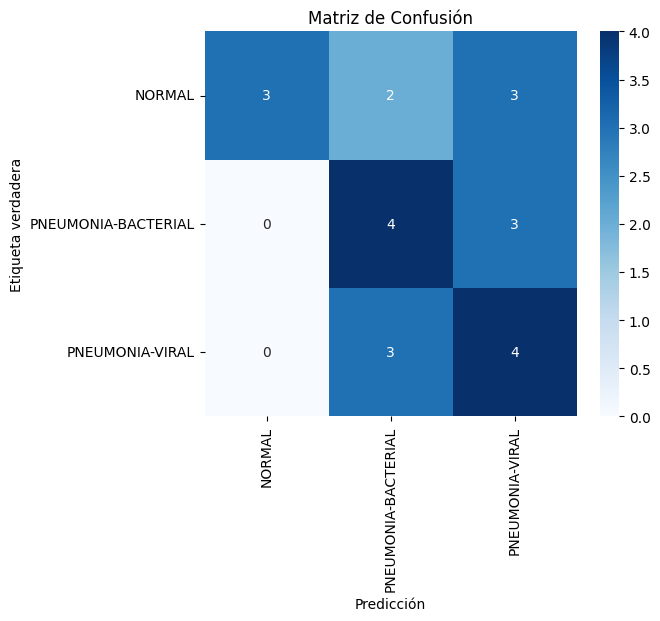

In [13]:
# ======================
# 9. EVALUACIÓN FINAL DEL MODELO
# ======================

# Predicciones
y_probs = model.predict(val_ds)
y_pred = np.argmax(y_probs, axis=1)

# Etiquetas verdaderas
y_true = np.concatenate([np.argmax(label.numpy(), axis=1) for _, label in val_ds])
class_names = ['NORMAL', 'PNEUMONIA-BACTERIAL', 'PNEUMONIA-VIRAL']

# Métricas
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')
report = classification_report(y_true, y_pred, target_names=class_names)
cm = confusion_matrix(y_true, y_pred)

# Resultados
print("🔍 Accuracy:", acc)
print("📐 F1 Score (ponderado):", f1)
print("\n📋 Reporte de Clasificación:\n", report)

# Matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta verdadera")
plt.title("Matriz de Confusión")
plt.show()